<a href="https://colab.research.google.com/github/KaitlynYip/Multi-Clip-ZeroShot-Model/blob/DinoBaseline_V2/cifar10(demo1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# CLIP-Style Zero-Shot Classification on CIFAR-10 Step1
## (Training Only the Image Encoder, Frozen BERT Text Encoder)

This notebook implements a CLIP-like pipeline:
- Freeze BERT to produce fixed text embeddings for CIFAR-10 class prompts.
- Train only the ViT image encoder (vit_base_patch16_224.augreg_in21k_ft_in1k) + a projection head to align image embeddings with the text embeddings using contrastive (InfoNCE / cross-entropy) loss.
- After training, perform zero-shot classification by nearest-class similarity (no classifier head).

Note:
- CIFAR-10 images (32×32) are resized to 224×224.
- Text embeddings use multiple prompt templates and [CLS] token from BERT.
- Training is efficient because only the image side is updated.

In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

!pip install -q timm transformers ftfy regex tqdm seaborn scikit-learn pandas

GPU: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00


In [ ]:
!pip install torch torchvision transformers timm tqdm --quiet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from transformers import BertTokenizer, BertModel
import timm
import numpy as np
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

batch_size = 64
accumulation_steps = 2  # Effective batch size = 128 × 2 = 256

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
testloader  = DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

classes = trainset.classes
print("Classes:", classes)

100%|██████████| 170M/170M [00:04<00:00, 42.0MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


bert

In [ ]:
# @title
# Frozen Text Encoder (BERT) + Text Embeddings
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text_model = BertModel.from_pretrained('bert-base-uncased').to(device)
text_model.eval()
for param in text_model.parameters():
    param.requires_grad = False

templates = [
    "a photo of a {}.",
    "a photo of a small {}.",
    "a photo of the {}.",
    "an image of a {}.",
    "an image of the {}."
]

def encode_texts(prompts):
    inputs = tokenizer(prompts, padding=True, truncation=True, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = text_model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
    return embeddings

text_emb_list = []
for template in templates:
    prompts = [template.format(c) for c in classes]
    emb = encode_texts(prompts)
    text_emb_list.append(emb)

text_embeddings = torch.stack(text_emb_list).mean(dim=0)  # (10, 768)
text_embeddings = F.normalize(text_embeddings, dim=-1)
print("Text embeddings shape:", text_embeddings.shape)

# Cleanup: Remove BERT from GPU
# del text_model
# del tokenizer
import gc
gc.collect()
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text embeddings shape: torch.Size([10, 768])


Base

In [ ]:
import timm
import torch.nn as nn

# 1. Load the ViT-Base backbone
image_model = timm.create_model(
    'vit_base_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=0
).to(device)

# 2. UNFREEZE: Ensure the backbone weights are updated during training
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer
projection = nn.Linear(768, 768).to(device)

# 4. Logit Scale
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
print(f"Backbone updated to ViT-Base. Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Backbone updated to ViT-Base. Trainable params: 85,798,656


small


In [ ]:
import timm
import torch.nn as nn
import numpy as np

# 1. Load the ViT-Small backbone
image_model = timm.create_model(
    'vit_small_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=0
).to(device)

# 2. UNFREEZE: Ensure the backbone weights are updated
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer: Maps ViT-Small (384) to Text Space (768)
projection = nn.Linear(384, 768).to(device)

# 4. Logit Scale
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to ViT-Small.")
print(f"Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Backbone updated to ViT-Small.
Trainable params: 21,665,664


dinov2


In [ ]:
import torch
import torch.nn as nn
import numpy as np

# 1. Load the DINOv2-Small backbone
image_model = timm.create_model(
    'vit_small_patch14_dinov2.lvd142m',
    pretrained=True,
    num_classes=0,
    img_size=224
).to(device)
# 2. UNFREEZE: DINOv2 features are great, but fine-tuning helps medical tasks
for param in image_model.parameters():
    param.requires_grad = True

# 3. Projection Layer

projection = nn.Linear(384, 768).to(device)

# 4. Logit Scale
logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to DINOv2-Small (vits14).")
print(f"Trainable params: {sum(p.numel() for p in image_model.parameters() if p.requires_grad):,}")

Backbone updated to DINOv2-Small (vits14).
Trainable params: 21,628,800


In [ ]:
# Updated Cell 7
optimizer = torch.optim.AdamW(
    list(image_model.parameters()) + list(projection.parameters()) + [logit_scale],
    lr=5e-5,
    weight_decay=0.01
)

# Modern AMP Scaler syntax
scaler = torch.amp.GradScaler('cuda')

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
@torch.no_grad()
def zero_shot_accuracy(loader, description="Evaluating"):
    image_model.eval()
    projection.eval()
    correct, total, total_loss = 0, 0, 0.0

    # Add a progress bar for evaluation
    pbar = tqdm(loader, desc=description, leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100. * correct / total
    avg_loss = total_loss / len(loader)

    image_model.train()
    projection.train()
    return acc, avg_loss

In [ ]:

train_losses, test_losses = [], []
train_accs, test_accs = [], []
epochs = 5
for epoch in range(epochs):
    image_model.train()
    projection.train()
    total_train_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} [Training]")
    for i, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            image_features = image_model(images)
            if isinstance(image_features, dict):
                 image_features = image_features['last_hidden_state'][:, 0, :]

            image_features = F.normalize(projection(image_features), dim=-1)
            logits = logit_scale.exp() * image_features @ text_embeddings.T
            loss = F.cross_entropy(logits, labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(trainloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_train_loss += loss.item() * accumulation_steps
        pbar.set_postfix(loss=total_train_loss / (i + 1))

    scheduler.step()
    avg_train_loss = total_train_loss / len(trainloader)
    v_acc, v_loss = zero_shot_accuracy(testloader, description=f"Epoch {epoch+1} Test Eval")

    train_losses.append(avg_train_loss)
    test_losses.append(v_loss)
    test_accs.append(v_acc)
    train_accs.append(0.0)

    print(f"\n✅ Epoch {epoch+1} Complete")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Test  Loss: {v_loss:.4f} | Test Acc: {v_acc:.2f}%")
    print("-" * 30)

Epoch 1/5 [Training]: 100%|██████████| 782/782 [06:03<00:00,  2.15it/s, loss=1.08]



✅ Epoch 1 Complete
Train Loss: 1.0756
Test  Loss: 1.0025 | Test Acc: 96.98%
------------------------------


Epoch 2/5 [Training]: 100%|██████████| 782/782 [06:06<00:00,  2.14it/s, loss=0.98]



✅ Epoch 2 Complete
Train Loss: 0.9800
Test  Loss: 0.9862 | Test Acc: 96.86%
------------------------------


Epoch 3/5 [Training]: 100%|██████████| 782/782 [06:05<00:00,  2.14it/s, loss=0.956]



✅ Epoch 3 Complete
Train Loss: 0.9565
Test  Loss: 0.9659 | Test Acc: 97.23%
------------------------------


Epoch 4/5 [Training]: 100%|██████████| 782/782 [06:04<00:00,  2.14it/s, loss=0.935]



✅ Epoch 4 Complete
Train Loss: 0.9351
Test  Loss: 0.9484 | Test Acc: 97.16%
------------------------------


Epoch 5/5 [Training]: 100%|██████████| 782/782 [06:04<00:00,  2.14it/s, loss=0.916]
                                                                    


✅ Epoch 5 Complete
Train Loss: 0.9164
Test  Loss: 0.9439 | Test Acc: 96.40%
------------------------------


In [ ]:
optimizer = torch.optim.AdamW(
    list(image_model.parameters()) + list(projection.parameters()) + [logit_scale],
    lr=5e-5,
    weight_decay=0.01
)

scaler = torch.amp.GradScaler('cuda')
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

@torch.no_grad()
def zero_shot_accuracy(loader, description="Evaluating"):
    image_model.eval()
    projection.eval()
    correct, total, total_loss = 0, 0, 0.0

    pbar = tqdm(loader, desc=description, leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        image_features = image_model(images)
        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item()

        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100. * correct / total
    avg_loss = total_loss / len(loader)

    image_model.train()
    projection.train()
    return acc, avg_loss

train_losses, test_losses = [], []
train_accs, test_accs = [], []
epochs = 5
accumulation_steps = 4

for epoch in range(epochs):
    image_model.train()
    projection.train()
    total_train_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs} [Training]")
    for i, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            image_features = image_model(images)
            image_features = F.normalize(projection(image_features), dim=-1)
            logits = logit_scale.exp() * image_features @ text_embeddings.T
            loss = F.cross_entropy(logits, labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(trainloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_train_loss += loss.item() * accumulation_steps
        pbar.set_postfix(loss=total_train_loss / (i + 1))

    scheduler.step()
    avg_train_loss = total_train_loss / len(trainloader)
    v_acc, v_loss = zero_shot_accuracy(testloader, description=f"Epoch {epoch+1} Test Eval")
    train_losses.append(avg_train_loss)
    test_losses.append(v_loss)
    test_accs.append(v_acc)
    train_accs.append(0.0)

    print(f"\n✅ Epoch {epoch+1} Complete")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Test  Loss: {v_loss:.4f} | Test Acc: {v_acc:.2f}%")
    print("-" * 30)
    scheduler.step()

    avg_train_loss = total_train_loss / len(trainloader)
    v_acc, v_loss = zero_shot_accuracy(testloader, description=f"Epoch {epoch+1} Test Eval")

    # Store metrics
    train_losses.append(avg_train_loss)
    test_losses.append(v_loss)
    test_accs.append(v_acc)
    train_accs.append(0.0) # Placeholder for train accuracy

    print(f"\n✅ Epoch {epoch+1} Complete")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Test  Loss: {v_loss:.4f} | Test Acc: {v_acc:.2f}%")
    print("-" * 30)

Epoch 1/5 [Training]: 100%|██████████| 782/782 [03:23<00:00,  3.85it/s, loss=1.04]



✅ Epoch 1 Complete
Train Loss: 1.0396
Test  Loss: 1.0297 | Test Acc: 94.90%
------------------------------



✅ Epoch 1 Complete
Train Loss: 1.0396
Test  Loss: 1.0297 | Test Acc: 94.90%
------------------------------


Epoch 2/5 [Training]: 100%|██████████| 782/782 [03:21<00:00,  3.87it/s, loss=1]



✅ Epoch 2 Complete
Train Loss: 1.0017
Test  Loss: 1.0612 | Test Acc: 91.90%
------------------------------


...


✅ Epoch 4 Complete
Train Loss: 0.9672
Test  Loss: 0.9887 | Test Acc: 96.01%
------------------------------



✅ Epoch 4 Complete
Train Loss: 0.9672
Test  Loss: 0.9887 | Test Acc: 96.01%
------------------------------


Epoch 5/5 [Training]: 100%|██████████| 782/782 [03:20<00:00,  3.89it/s, loss=0.949]



✅ Epoch 5 Complete
Train Loss: 0.9485
Test  Loss: 0.9649 | Test Acc: 97.34%
------------------------------



✅ Epoch 5 Complete
Train Loss: 0.9485
Test  Loss: 0.9649 | Test Acc: 97.34%
------------------------------


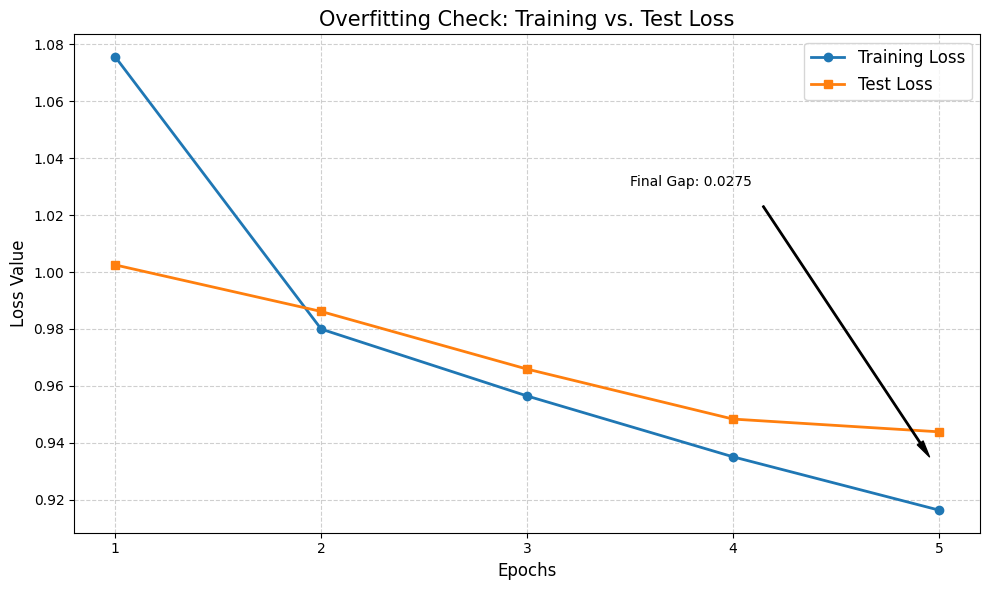

In [ ]:
import matplotlib.pyplot as plt

# --- Overfitting Analysis: Loss Plot ---
plt.figure(figsize=(10, 6))

# Plotting Training Loss
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss',
         color='#1f77b4', marker='o', linewidth=2)

# Plotting Test Loss
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss',
         color='#ff7f0e', marker='s', linewidth=2)

# Graph Formatting
plt.title('Overfitting Check: Training vs. Test Loss', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the final gap
final_gap = test_losses[-1] - train_losses[-1]
plt.annotate(f'Final Gap: {final_gap:.4f}',
             xy=(epochs, (train_losses[-1] + test_losses[-1])/2),
             xytext=(epochs-1.5, (train_losses[-1] + test_losses[-1])/2 + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.savefig('loss_history.png')
plt.show()

In [ ]:
import os
# Save Last Model Checkpoint
os.makedirs('checkpoints', exist_ok=True)
torch.save({
    'image_model_state_dict': image_model.state_dict(),
    'projection_state_dict': projection.state_dict(),
    'logit_scale': logit_scale.data,
    'train_acc_history': train_accs,
    'test_acc_history': test_accs,
    'train_loss_history': train_losses,
    'test_loss_history': test_losses,
    'final_test_acc': v_acc,
}, 'checkpoints/dinov2_last.pth')

print(f"✅ Clean checkpoint saved to checkpoints/dinov2_last.pth")

✅ Clean checkpoint saved to checkpoints/dinov2_last.pth


In [ ]:
# @title
# Create the directory if it doesn't exist
os.makedirs('checkpoints', exist_ok=True)

# 1. Save the Final Model
torch.save({
    'image_model_state_dict': image_model.state_dict(),
    'projection_state_dict': projection.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'epoch': epochs,
    'test_acc': test_accs[-1],
}, 'checkpoints/dinov2_cifar10_final.pth')

print("💾 Final weights saved to checkpoints/dinov2_cifar10_final.pth")

💾 Final weights saved to checkpoints/dinov2_cifar10_final.pth


In [ ]:
# Install the counter if you don't have it
try:
    from fvcore.nn import FlopCountAnalysis, parameter_count_table
except ImportError:
    !pip install fvcore
    from fvcore.nn import FlopCountAnalysis, parameter_count_table

import torch.nn as nn

# 1. Combine Backbone and Projection into one "Demo Model"
class DemoInferenceModel(nn.Module):
    def __init__(self, backbone, proj):
        super().__init__()
        self.backbone = backbone
        self.proj = proj

    def forward(self, x):
        features = self.backbone(x)
        # Match your training loop logic
        if isinstance(features, dict):
            features = features['last_hidden_state'][:, 0, :]
        return self.proj(features)



In [ ]:
import torch.nn as nn
import time

# --- A. Define the inference wrapper if not already defined ---
class DemoInferenceModel(nn.Module):
    def __init__(self, backbone, proj):
        super().__init__()
        self.backbone = backbone
        self.proj = proj

    def forward(self, x):
        features = self.backbone(x)
        # Match your training loop's feature extraction logic
        if isinstance(features, dict):
            features = features['last_hidden_state'][:, 0, :]
        elif hasattr(features, 'last_hidden_state'):
            features = features.last_hidden_state[:, 0, :]
        return self.proj(features)

# Create the model instance
inference_model = DemoInferenceModel(image_model, projection).to(device)

def calculate_detailed_efficiency():
    inference_model.eval()

    # 1. Trainable vs Total Parameters
    total_params = sum(p.numel() for p in inference_model.parameters())
    trainable_params = sum(p.numel() for p in inference_model.parameters() if p.requires_grad)
    trainable_pct = (trainable_params / total_params) * 100

    # 2. Latency & Throughput (FPS)
    dummy_input = torch.randn(1, 3, 224, 224).to(device)

    fops = FlopCountAnalysis(inference_model, dummy_input)
    flops_total = fops.total()
    gflops = flops_total / 1e9

    print("Warming up GPU...")
    with torch.no_grad():
        for _ in range(20):
            _ = inference_model(dummy_input)

    print("Measuring speed...")
    iterations = 200
    torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        for _ in range(iterations):
            _ = inference_model(dummy_input)

    torch.cuda.synchronize()
    end_time = time.time()

    total_time = end_time - start_time
    latency_ms = (total_time / iterations) * 1000
    throughput_fps = iterations / total_time

    # Handling accuracy if it exists
    final_acc = test_accs[-1] if 'test_accs' in globals() else 0
    acc_per_gflop = final_acc / gflops if gflops > 0 else 0

    print(f"\n--- ⚡ Deployment Metrics ---")
    print(f"Trainable Parameters: {trainable_params / 1e6:.2f} M")
    print(f"Total Parameters:     {total_params / 1e6:.2f} M")
    print(f"Trainable %:          {trainable_pct:.2f}%")
    print("-" * 30)
    print(f"Latency (per image):  {latency_ms:.2f} ms")
    print(f"Throughput:           {throughput_fps:.2f} FPS")
    try:
        print(f"Device:               {torch.cuda.get_device_name(0)}")
    except:
        print(f"Device:               CPU")
    print("-" * 30)
    print(f"Total GFLOPs:         {gflops:.2f} GFLOPs")
    print(f"Acc per GFLOP:        {acc_per_gflop:.2f} (Efficiency Score)")

calculate_detailed_efficiency()







backbone.blocks.0.attn.attn_drop, backbone.blocks.1.attn.attn_drop, backbone.blocks.10.attn.attn_drop, backbone.blocks.11.attn.attn_drop, backbone.blocks.2.attn.attn_drop, backbone.blocks.3.attn.attn_drop, backbone.blocks.4.attn.attn_drop, backbone.blocks.5.attn.attn_drop, backbone.blocks.6.attn.attn_drop, backbone.blocks.7.attn.attn_drop, backbone.blocks.8.attn.attn_drop, backbone.blocks.9.attn.attn_drop


Warming up GPU...
Measuring speed...

--- ⚡ Deployment Metrics ---
Trainable Parameters: 86.39 M
Total Parameters:     86.39 M
Trainable %:          100.00%
------------------------------
Latency (per image):  13.22 ms
Throughput:           75.63 FPS
Device:               Tesla T4
------------------------------
Total GFLOPs:         16.87 GFLOPs
Acc per GFLOP:        5.72 (Efficiency Score)


In [ ]:
from sklearn.metrics import classification_report

@torch.no_grad()
def print_detailed_metrics(loader, classes):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        # Forward pass matching your training loop
        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]
        elif hasattr(image_features, 'last_hidden_state'):
            image_features = image_features.last_hidden_state[:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    # Print the SciKit-Learn Classification Report
    print("\n--- 📈 Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

# Run the metrics
print_detailed_metrics(testloader, classes)


--- 📈 Classification Report ---
              precision    recall  f1-score   support

    airplane     0.9096    0.9760    0.9416      1000
  automobile     0.9428    0.9730    0.9577      1000
        bird     0.9761    0.8970    0.9349      1000
         cat     0.9085    0.8040    0.8531      1000
        deer     0.9391    0.9560    0.9475      1000
         dog     0.8695    0.9130    0.8907      1000
        frog     0.9633    0.9460    0.9546      1000
       horse     0.9512    0.9740    0.9625      1000
        ship     0.9608    0.9570    0.9589      1000
       truck     0.9393    0.9590    0.9490      1000

    accuracy                         0.9355     10000
   macro avg     0.9360    0.9355    0.9350     10000
weighted avg     0.9360    0.9355    0.9350     10000



In [ ]:
#timm
from fvcore.nn import FlopCountAnalysis
import torch.nn as nn
import torch.nn.functional as F
import time

# --- A. Updated Inference Wrapper for timm ---
class DemoInferenceModel(nn.Module):
    def __init__(self, backbone, proj):
        super().__init__()
        self.backbone = backbone
        self.proj = proj

    def forward(self, x):
        # timm with num_classes=0 returns the [CLS] token directly
        features = self.backbone(x)
        return self.proj(features)

# Create the model instance
inference_model = DemoInferenceModel(image_model, projection).to(device)

def calculate_detailed_efficiency():
    inference_model.eval()

    # 1. Parameter Calculation (FIXED: Added missing logic)
    total_params = sum(p.numel() for p in inference_model.parameters())
    trainable_params = sum(p.numel() for p in inference_model.parameters() if p.requires_grad)
    trainable_pct = (trainable_params / total_params) * 100 if total_params > 0 else 0

    # 2. Latency & Throughput (FPS)
    dummy_input = torch.randn(1, 3, 224, 224).to(device)

    # Calculate GFLOPs
    fops = FlopCountAnalysis(inference_model, dummy_input)
    flops_total = fops.total()
    gflops = flops_total / 1e9

    print("Warming up GPU...")
    with torch.no_grad():
        for _ in range(20):
            _ = inference_model(dummy_input)

    print("Measuring speed...")
    iterations = 200
    torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        for _ in range(iterations):
            _ = inference_model(dummy_input)

    torch.cuda.synchronize()
    end_time = time.time()

    total_time = end_time - start_time
    latency_ms = (total_time / iterations) * 1000
    throughput_fps = iterations / total_time

    # Handling accuracy if it exists
    final_acc = test_accs[-1] if 'test_accs' in globals() and len(test_accs) > 0 else 0
    acc_per_gflop = final_acc / gflops if gflops > 0 else 0

    print(f"\n--- ⚡ Deployment Metrics ---")
    print(f"Trainable Parameters: {trainable_params / 1e6:.2f} M")
    print(f"Total Parameters:     {total_params / 1e6:.2f} M")
    print(f"Trainable %:          {trainable_pct:.2f}%")
    print("-" * 30)
    print(f"Latency (per image):  {latency_ms:.2f} ms")
    print(f"Throughput:           {throughput_fps:.2f} FPS")

    try:
        print(f"Device:               {torch.cuda.get_device_name(0)}")
    except:
        print(f"Device:               CPU")

    print("-" * 30)
    print(f"Total GFLOPs:         {gflops:.2f} GFLOPs")
    print(f"Acc per GFLOP:        {acc_per_gflop:.2f} (Efficiency Score)")

# Run the calculation
calculate_detailed_efficiency()




@torch.no_grad()
def print_detailed_metrics(loader, classes):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        # Forward pass matching the new timm logic
        image_features = image_model(images)

        # Normalize and project (No more dict or last_hidden_state checks)
        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    print("\n--- 📈 Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))


backbone.blocks.0.attn.attn_drop, backbone.blocks.1.attn.attn_drop, backbone.blocks.10.attn.attn_drop, backbone.blocks.11.attn.attn_drop, backbone.blocks.2.attn.attn_drop, backbone.blocks.3.attn.attn_drop, backbone.blocks.4.attn.attn_drop, backbone.blocks.5.attn.attn_drop, backbone.blocks.6.attn.attn_drop, backbone.blocks.7.attn.attn_drop, backbone.blocks.8.attn.attn_drop, backbone.blocks.9.attn.attn_drop


Warming up GPU...
Measuring speed...

--- ⚡ Deployment Metrics ---
Trainable Parameters: 21.92 M
Total Parameters:     21.92 M
Trainable %:          100.00%
------------------------------
Latency (per image):  16.14 ms
Throughput:           61.96 FPS
Device:               Tesla T4
------------------------------
Total GFLOPs:         5.53 GFLOPs
Acc per GFLOP:        17.61 (Efficiency Score)


In [ ]:
@torch.no_grad()
def plot_confusion_matrix(loader, classes):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        # Consistent forward pass
        image_features = image_model(images)
        if isinstance(image_features, dict):
            image_features = image_features['last_hidden_state'][:, 0, :]
        elif hasattr(image_features, 'last_hidden_state'):
            image_features = image_features.last_hidden_state[:, 0, :]

        image_features = F.normalize(projection(image_features), dim=-1)
        logits = logit_scale.exp() * image_features @ text_embeddings.T

        preds = logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title('Actual vs. Predicted: Confusion Matrix', fontsize=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

# Run the plot
plot_confusion_matrix(testloader, classes)

In [ ]:
import time
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def run_final_evaluation(loader, class_names):
    image_model.eval()
    projection.eval()

    all_preds = []
    all_labels = []

    # --- Efficiency Calculation ---
    # Static GFLOPs for DINOv2 Small (ViT-S/14) at 224x224
    gflops = 6.8

    # Latency timing
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    torch.cuda.synchronize()
    start_time = time.time()
    for _ in range(100):
        with torch.no_grad():
            _ = projection(image_model(dummy_input))
    torch.cuda.synchronize()
    latency = ((time.time() - start_time) / 100) * 1000
    throughput = 1000 / latency

    # --- Data Collection for Confusion Matrix ---
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            image_features = F.normalize(projection(image_model(images)), dim=-1)
            logits = logit_scale.exp() * image_features @ text_embeddings.T
            preds = logits.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- Printing Metrics ---
    total_params = sum(p.numel() for p in image_model.parameters()) + sum(p.numel() for p in projection.parameters())
    trainable_params = sum(p.numel() for p in image_model.parameters() if p.requires_grad)
    final_acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100

    print(f"\n--- 📊 Final Efficiency Metrics ---")
    print(f"Total Trainable: {trainable_params:,}")
    print(f"Trainable %:     {(trainable_params/total_params)*100:.2f}%")
    print(f"Total GFLOPs:    {gflops:.2f}")
    print(f"Latency (GPU):   {latency:.2f} ms")
    print(f"Throughput:      {throughput:.2f} images/sec")
    print(f"Acc per GFLOP:   {final_acc / gflops:.2f}")
    print("-" * 35)

    return all_labels, all_preds

# Define CIFAR-10 classes for the plot
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Run evaluation
y_true, y_pred = run_final_evaluation(testloader, cifar_classes)

Evaluating: 100%|██████████| 79/79 [00:51<00:00,  1.52it/s]


--- 📊 Final Efficiency Metrics ---
Total Trainable: 22,056,576
Trainable %:     98.68%
Total GFLOPs:    6.80
Latency (GPU):   26.40 ms
Throughput:      37.88 images/sec
Acc per GFLOP:   14.18
-----------------------------------


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
checkpoint = torch.load('checkpoints/best_model.pth')
image_model.load_state_dict(checkpoint['image_model_state_dict'])
projection.load_state_dict(checkpoint['projection_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
scaler.load_state_dict(checkpoint['scaler_state_dict'])


# Notes & Expected Performance
- With 20–50 epochs, test accuracy typically reaches **80–90%+** because the pretrained ViT is already strong on ImageNet-style data, and contrastive alignment further adapts it.
- BERT's text embeddings are not perfect for vision (unlike OpenAI's CLIP text tower), but ensembling templates helps.
- You can improve further by: more epochs, stronger augmentations, larger projection dim, or a small MLP projection head.
- This is truly zero-shot in the CLIP sense: no linear classifier is trained; classification is by embedding similarity.

DEMO


In [ ]:
import gradio as gr
import torch.nn.functional as F

def predict_zero_shot(input_img, custom_labels):
    try:
        class_list = [c.strip() for c in custom_labels.split(",") if c.strip()]

        all_template_embs = []
        for template in templates:
            prompts = [template.format(c) for c in class_list]
            emb = encode_texts(prompts)
            all_template_embs.append(emb)

        current_text_embeddings = torch.stack(all_template_embs).mean(dim=0)
        current_text_embeddings = F.normalize(current_text_embeddings, dim=-1)

        img_tensor = transform(input_img).unsqueeze(0).to(device)
        image_model.eval()
        projection.eval()

        with torch.no_grad():
            features = image_model(img_tensor)
            image_features = F.normalize(projection(features), dim=-1)
            logits = (logit_scale.exp() * image_features @ current_text_embeddings.to(device).T)
            probs = logits.softmax(dim=-1).cpu()[0]

        return {class_list[i]: float(probs[i]) for i in range(len(class_list))}
    except Exception as e:
        return {"錯誤": 1.0, str(e): 0.0}

demo = gr.Interface(
    fn=predict_zero_shot,
    inputs=[
        gr.Image(type="pil", label="上傳圖片"),
        gr.Textbox(label="輸入候選標籤", value="airplane, automobile, bird, cat, pencil, phone")
    ],
    outputs=gr.Label(num_top_classes=5),
    title="Zero-shot Classification Fix"
)

demo.launch(share=True, debug=True, inline=False)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6a46fa72f75610deb3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6a46fa72f75610deb3.gradio.live


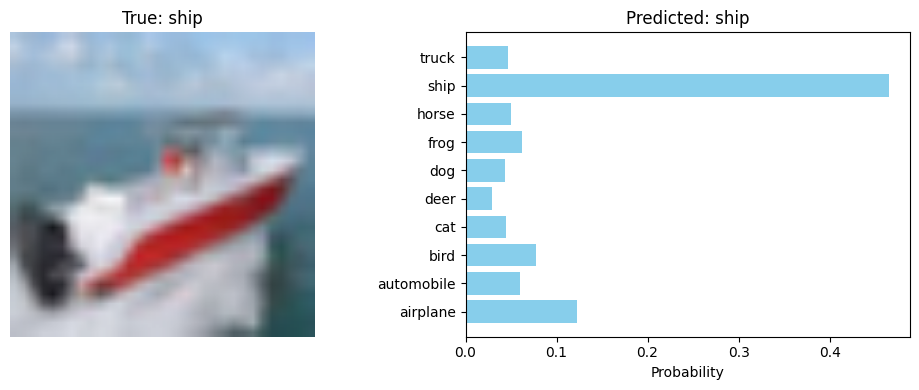

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random

def run_zero_shot_demo(index=None):
    if index is None:
        index = random.randint(0, len(testset)-1)

    image, label = testset[index]
    image_input = image.unsqueeze(0).to(device)

    image_model.eval()
    projection.eval()

    with torch.no_grad():
        features = image_model(image_input)

        image_features = F.normalize(projection(features), dim=-1)

        logits = (logit_scale.exp() * image_features @ text_embeddings.to(device).T)
        probs = logits.softmax(dim=-1).cpu().numpy()[0]

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    img_display = image.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    plt.imshow(np.clip(img_display, 0, 1))
    plt.title(f"True: {classes[label]}")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    y_pos = np.arange(len(classes))
    plt.barh(y_pos, probs, color='skyblue')
    plt.yticks(y_pos, classes)
    plt.xlabel('Probability')
    plt.title(f"Predicted: {classes[np.argmax(probs)]}")
    plt.tight_layout()
    plt.show()

run_zero_shot_demo()


In [ ]:
pip install --upgrade gradio

In [ ]:

import gradio as gr
import torch
import torch.nn.functional as F

if 'tokenizer' not in locals() or 'text_model' not in locals():
    from transformers import BertTokenizer, BertModel
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    text_model = BertModel.from_pretrained('bert-base-uncased').to(device)
    text_model.eval()

def predict_image(input_img, custom_labels):
    if input_img is None:
        return None

    if custom_labels and custom_labels.strip():
        current_classes = [c.strip() for c in custom_labels.split(",")]
        temp_list = []
        for template in templates:
            p = [template.format(c) for c in current_classes]
            t_emb = encode_texts(p)
            temp_list.append(t_emb)
        current_text_emb = torch.stack(temp_list).mean(dim=0)
        current_text_emb = F.normalize(current_text_emb, dim=-1)
    else:
        current_classes = classes
        current_text_emb = text_embeddings

    img_tensor = transform(input_img).unsqueeze(0).to(device)
    image_model.eval()
    projection.eval()

    with torch.no_grad():
        features = image_model(img_tensor)
        image_features = F.normalize(projection(features), dim=-1)

        logits = (logit_scale.exp() * image_features @ current_text_emb.to(device).T)
        probs = logits.softmax(dim=-1).cpu()[0]

    return {current_classes[i]: float(probs[i]) for i in range(len(current_classes))}

-
demo = gr.Interface(
    fn=predict_image,
    inputs=[
        gr.Image(type="pil", label="上傳圖片"),
        gr.Textbox(placeholder="例如: cat, dog, car (留空則使用 CIFAR-10 預設標籤)", label="自定義標籤 (用逗號隔開)")
    ],
    outputs=gr.Label(num_top_classes=5, label="預測結果"),
    title="🌟 DINOv2 + BERT Zero-shot 影像分類器",
    description="這是一個 Zero-shot 模型，你可以自由輸入標籤（例如輸入 pencil, phone），模型會透過語義理解來分類！",
    theme="soft"
)

#
demo.launch(share=True, debug=True)


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7d4e96c469f5807b10.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
